In [2]:
from datasets import load_dataset

dataset_train = load_dataset(
    'cifar10',
    split = 'train'
)
dataset_train

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/120M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/23.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Dataset({
    features: ['img', 'label'],
    num_rows: 50000
})

In [3]:
num_classes = len(set(dataset_train['label']))
num_classes

10

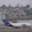

In [4]:
dataset_train[0]['img']

In [5]:
import torchvision.transforms as transforms

img_size = 32

preprocess = transforms.Compose([
    transforms.Resize((img_size,img_size)),
    transforms.ToTensor()
])

In [6]:
from tqdm.auto import tqdm

inputs_train = []

for record in tqdm(dataset_train):
  image = record['img']
  label = record['label']

  if image.mode == 'L':
    image = image.convert("RGB")

  input_tensor = preprocess(image)

  inputs_train.append([input_tensor,label])



  0%|          | 0/50000 [00:00<?, ?it/s]

In [7]:
print(len(inputs_train),inputs_train[0][0].shape)

50000 torch.Size([3, 32, 32])


In [8]:
mean = [0.4670, 0.4735, 0.4662]
std = [0.2496, 0.2489, 0.2521]

In [9]:
preprocess = transforms.Compose([
    transforms.Normalize(mean=mean,std=std)
])

for i in tqdm(range(len(inputs_train))):
  input_tensor = preprocess(inputs_train[i][0])
  inputs_train[i][0] = input_tensor

  0%|          | 0/50000 [00:00<?, ?it/s]

In [10]:
dataset_val = load_dataset(
    'cifar10',
    split = 'test'
)

In [11]:
from tqdm.auto import tqdm

inputs_val = []

for record in tqdm(dataset_val):
  image = record['img']
  label = record['label']

  if image.mode == 'L':
    image = image.convert("RGB")

  input_tensor = transforms.Compose([
      transforms.Resize((img_size,img_size)),
      transforms.ToTensor()
  ])(image)


  inputs_val.append([input_tensor,label])



  0%|          | 0/10000 [00:00<?, ?it/s]

In [12]:
preprocess_normalize = transforms.Compose([
    transforms.Normalize(mean=mean,std=std)
])

for i in tqdm(range(len(inputs_val))):
  input_tensor = preprocess_normalize(inputs_val[i][0])
  inputs_val[i][0] = input_tensor

  0%|          | 0/10000 [00:00<?, ?it/s]

In [13]:
import torch

batch_size = 64

dloader_train = torch.utils.data.DataLoader(
    inputs_train,
    batch_size = batch_size,
    shuffle=True
)

dloader_val = torch.utils.data.DataLoader(
    inputs_val,
    batch_size = batch_size,
    shuffle = False
)

In [14]:
from torch import nn

class ConvNeuralNet(nn.Module):
  def __init__(self,num_classes):
    super(ConvNeuralNet,self).__init__()
    self.conv_layer1 = nn.Conv2d(in_channels=3,out_channels=64,kernel_size=4,padding=1)
    self.relu1 = nn.ReLU()
    self.maxpool1 = nn.MaxPool2d(kernel_size=3,stride=2)

    self.conv_layer2 = nn.Conv2d(in_channels=64,out_channels=192,kernel_size=4,padding=1)
    self.relu2 = nn.ReLU()
    self.maxpool2 = nn.MaxPool2d(kernel_size=3,stride=2)

    self.conv_layer3 = nn.Conv2d(in_channels=192, out_channels=384, kernel_size=3, padding=1)
    self.relu3 = nn.ReLU()

    self.conv_layer4 = nn.Conv2d(in_channels=384, out_channels=256, kernel_size=3, padding=1)
    self.relu4 = nn.ReLU()

    self.conv_layer5 = nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1)
    self.relu5 = nn.ReLU()
    self.maxpool5 = nn.MaxPool2d(kernel_size=3, stride=2)

    self.dropout6 = nn.Dropout(p=0.5)
    self.fc6 = nn.Linear(1024,512)
    self.relu6 = nn.ReLU()
    self.dropout7 = nn.Dropout(p=0.5)
    self.fc7 = nn.Linear(512,256)
    self.relu7 = nn.ReLU()
    self.fc8 = nn.Linear(256,num_classes)

  def forward(self,x):
    out = self.conv_layer1(x)
    out = self.relu1(out)
    out = self.maxpool1(out)

    out = self.conv_layer2(out)
    out = self.relu2(out)
    out = self.maxpool2(out)

    out = self.conv_layer3(out)
    out = self.relu3(out)

    out = self.conv_layer4(out)
    out = self.relu4(out)

    out = self.conv_layer5(out)
    out = self.relu5(out)
    out = self.maxpool5(out)

    out = out.reshape(out.size(0),-1)

    out = self.dropout6(out)
    out = self.fc6(out)
    out = self.relu6(out)

    out = self.dropout7(out)
    out = self.fc7(out)
    out = self.relu7(out)

    out = self.fc8(out)
    return out


In [15]:
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = ConvNeuralNet(num_classes).to(device)


In [16]:
loss_func = nn.CrossEntropyLoss()
lr = 0.008

optimizer = torch.optim.SGD(
    model.parameters(),lr = lr
)

In [17]:
num_epochs = 50

for epoch in range(num_epochs):
  model.train()

  for i, (images,labels) in enumerate(dloader_train):

    images = images.to(device)
    labels = labels.to(device)

    outputs = model(images)
    loss = loss_func(outputs,labels)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()


  with torch.no_grad():

    model.eval()
    correct = 0
    total = 0
    all_val_loss = []
    for images, labels in dloader_val:
      images = images.to(device)
      labels = labels.to(device)
      outputs = model(images)
      total+=labels.size(0)

      predicted = torch.argmax(outputs,dim=1)
      correct+=(predicted==labels).sum().item()

      all_val_loss.append(loss_func(outputs,labels).item())

    mean_val_loss = sum(all_val_loss)/len(all_val_loss)
    mean_val_acc = 100*(correct/total)

    print(
        'Epoch [{}/{}], Loss: {:.4f}, Val-loss: {:.4f}, Val-acc: {:.1f}%'.format(
            epoch+1, num_epochs, loss.item(), mean_val_loss, mean_val_acc
        )
    )



Epoch [1/50], Loss: 2.3014, Val-loss: 2.3005, Val-acc: 12.6%
Epoch [2/50], Loss: 2.2917, Val-loss: 2.2721, Val-acc: 14.1%
Epoch [3/50], Loss: 2.0303, Val-loss: 2.0573, Val-acc: 22.3%
Epoch [4/50], Loss: 1.8227, Val-loss: 1.8773, Val-acc: 24.0%
Epoch [5/50], Loss: 1.8143, Val-loss: 1.8221, Val-acc: 26.9%
Epoch [6/50], Loss: 1.8225, Val-loss: 1.7730, Val-acc: 28.0%
Epoch [7/50], Loss: 1.8237, Val-loss: 1.7396, Val-acc: 31.5%
Epoch [8/50], Loss: 1.3926, Val-loss: 1.6946, Val-acc: 35.1%
Epoch [9/50], Loss: 1.8958, Val-loss: 1.5715, Val-acc: 41.0%
Epoch [10/50], Loss: 1.1294, Val-loss: 1.4233, Val-acc: 45.6%
Epoch [11/50], Loss: 1.4060, Val-loss: 1.5815, Val-acc: 41.3%
Epoch [12/50], Loss: 1.1757, Val-loss: 1.4634, Val-acc: 48.1%
Epoch [13/50], Loss: 1.0107, Val-loss: 1.5587, Val-acc: 44.4%
Epoch [14/50], Loss: 1.5799, Val-loss: 1.5593, Val-acc: 44.7%
Epoch [15/50], Loss: 1.1778, Val-loss: 1.0828, Val-acc: 60.3%
Epoch [16/50], Loss: 1.0404, Val-loss: 1.1126, Val-acc: 59.8%
Epoch [17/50], Lo

In [18]:
torch.save(model,'cnn.pt')

model = torch.load('cnn.pt',weights_only=False)
model.eval()

ConvNeuralNet(
  (conv_layer1): Conv2d(3, 64, kernel_size=(4, 4), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv_layer2): Conv2d(64, 192, kernel_size=(4, 4), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (maxpool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv_layer3): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu3): ReLU()
  (conv_layer4): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu4): ReLU()
  (conv_layer5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu5): ReLU()
  (maxpool5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout6): Dropout(p=0.5, inplace=False)
  (fc6): Linear(in_features=1024, out_features=512, bias=True)
  (relu6): ReLU()
  (dropout7): Dropout(p=0.5, inplace=False)
  (fc7): Linear(in_features=512, out_f

In [22]:
import torchvision.transforms as transforms

input_tensors = []

pil_to_tensor_transform = transforms.Compose([
    transforms.Resize((img_size,img_size)),
    transforms.ToTensor()
])

for image in dataset_test['img'][:10]:
  tensor = pil_to_tensor_transform(image)
  tensor = preprocess(tensor)
  input_tensors.append(tensor.to(device))

In [25]:
len(input_tensors)

10

In [26]:
input_tensors[0].shape

torch.Size([3, 32, 32])

In [28]:
input_tensors = torch.stack(input_tensors)
input_tensors.shape

torch.Size([10, 3, 32, 32])

In [29]:
outputs = model(input_tensors)

predicted = torch.argmax(outputs,dim=1)
predicted

tensor([6, 8, 8, 0, 6, 6, 1, 6, 3, 1], device='cuda:0')

In [30]:
dataset_test.features['label'].names

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

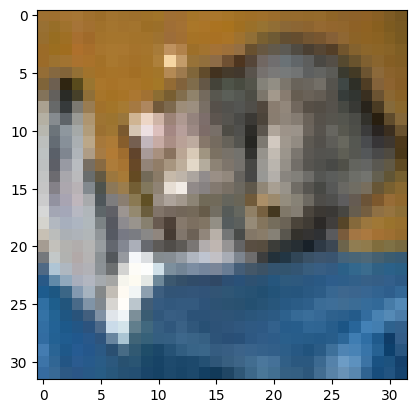

frog


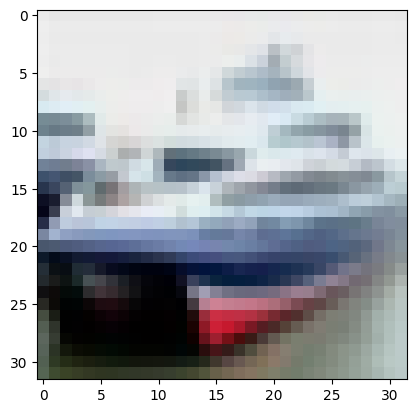

ship


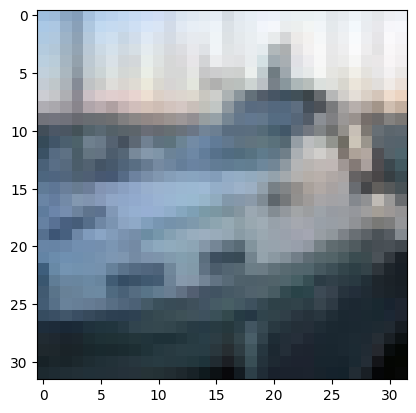

ship


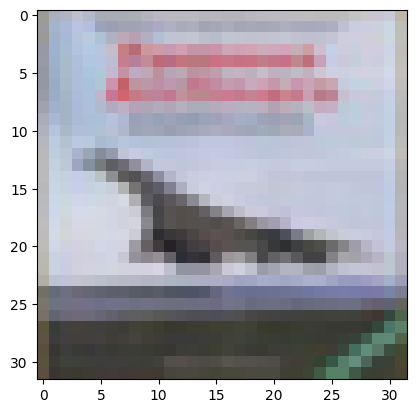

airplane


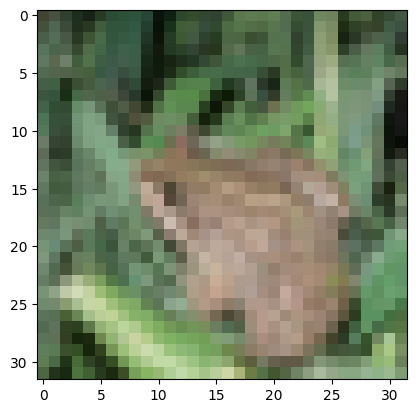

frog


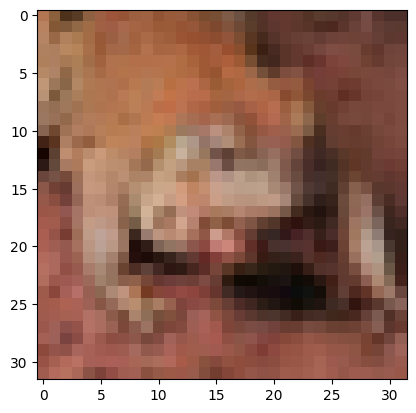

frog


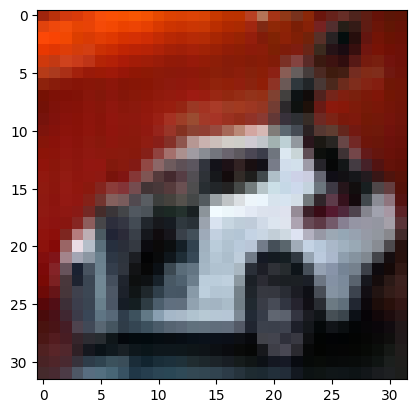

automobile


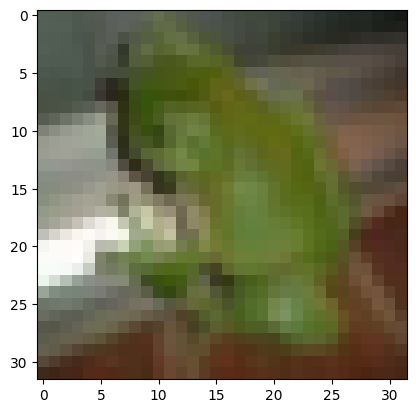

frog


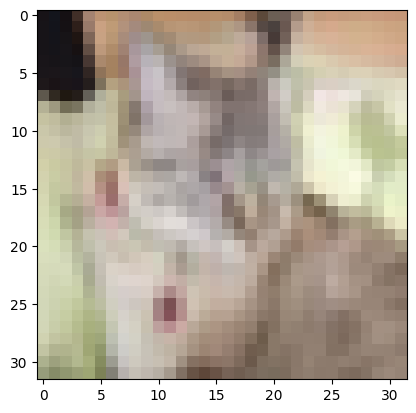

cat


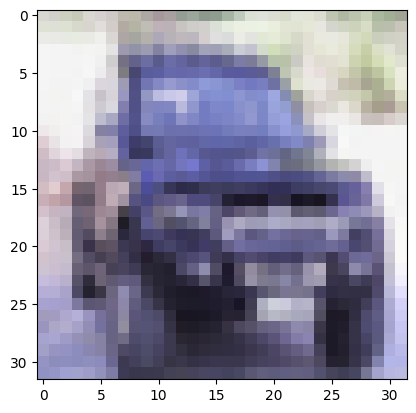

automobile


In [33]:
import matplotlib.pyplot as plt

for i, image in enumerate(dataset_test['img'][:10]):
  plt.imshow(image)
  plt.show()
  print(dataset_test.features['label'].names[predicted[i]])